Class Distribution (%):
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


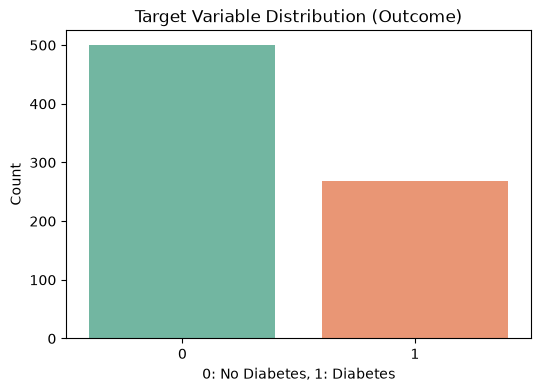

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 



columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

df = pd.read_csv('../data/pima-indians-diabetes.csv', names=columns)

cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

print("Class Distribution (%):")
print(df['Outcome'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, hue='Outcome', palette='Set2', legend=False)
plt.title('Target Variable Distribution (Outcome)')
plt.xlabel('0: No Diabetes, 1: Diabetes')
plt.ylabel('Count')
plt.show()

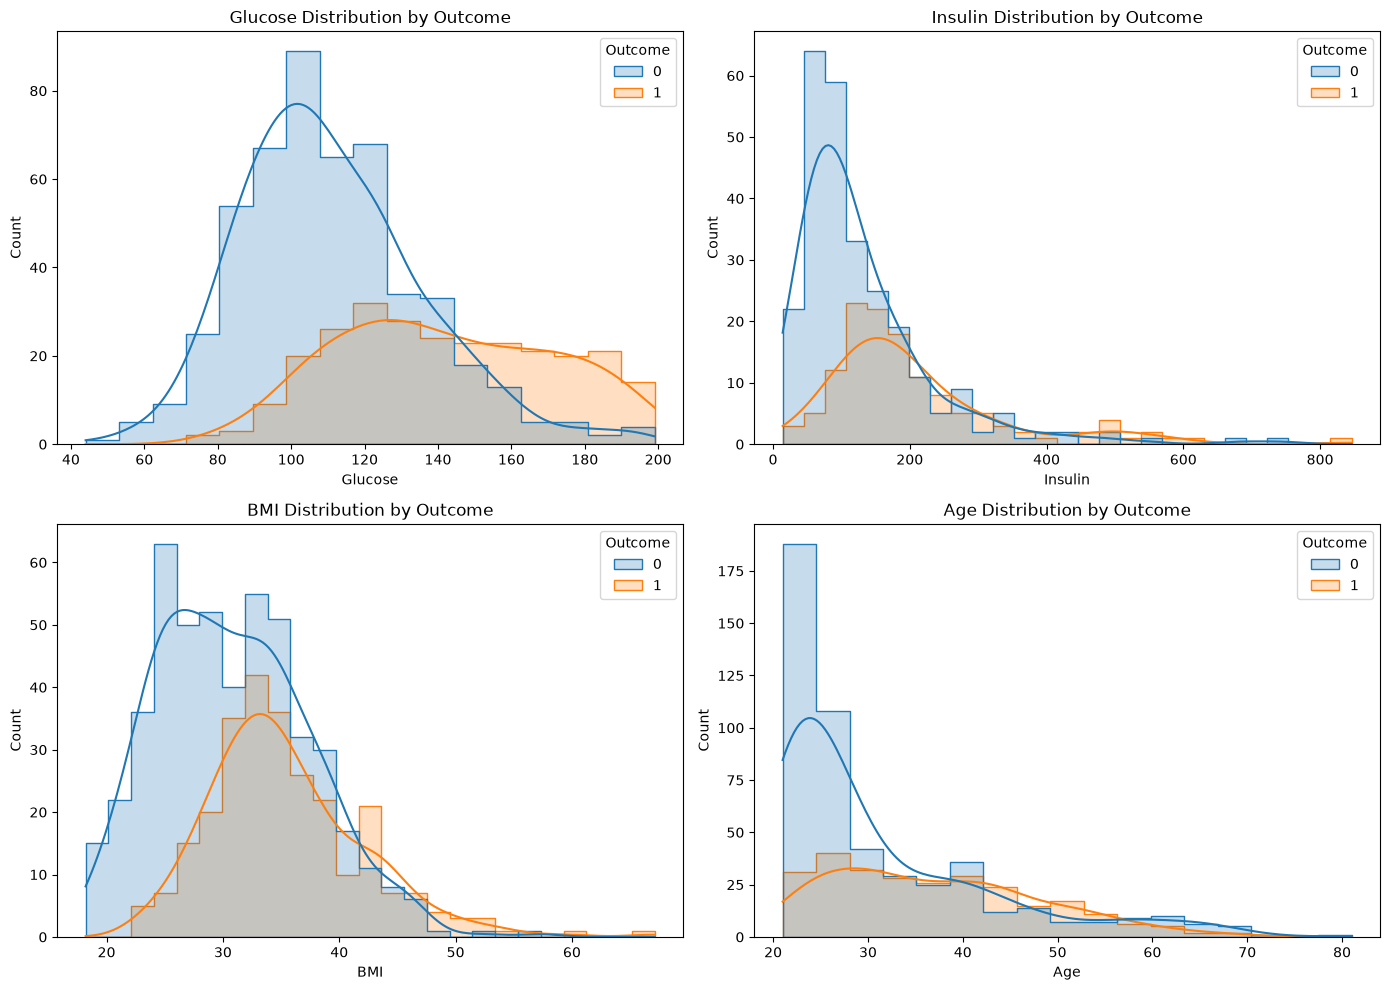

In [3]:
features = ['Glucose', 'Insulin', 'BMI', 'Age']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feat in zip(axes, features):
    sns.histplot(data=df, x=feat, hue='Outcome', kde=True, element='step', ax=ax)
    ax.set_title(f'{feat} Distribution by Outcome')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

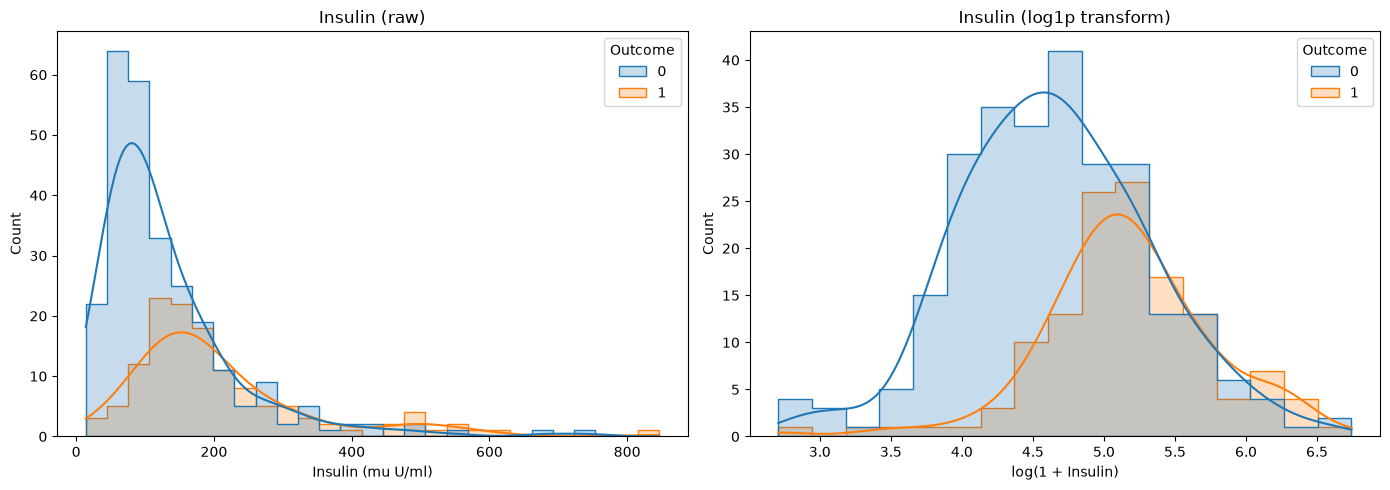

Insulin        2.166464
Insulin_log   -0.087830
dtype: float64


In [6]:
df['Insulin_log'] = np.log1p(df['Insulin'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Insulin', hue='Outcome', kde=True, element='step', ax=axes[0])
axes[0].set_title('Insulin (raw)')
axes[0].set_xlabel('Insulin (mu U/ml)')

sns.histplot(data=df, x='Insulin_log', hue='Outcome', kde=True, element='step', ax=axes[1])
axes[1].set_title('Insulin (log1p transform)')
axes[1].set_xlabel('log(1 + Insulin)')

plt.tight_layout()
plt.show()

print(df[['Insulin', 'Insulin_log']].skew())


In [8]:

Q1 = df['Glucose'].quantile(0.25)
Q3 = df['Glucose'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Glucose Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")

outliers_count = ((df['Glucose'] < lower_bound) | (df['Glucose'] > upper_bound)).sum()
total_rows = len(df)

print(f"Outliers found: {outliers_count} ({outliers_count/total_rows*100:.2f}% of data)")

Glucose Bounds: [36.00, 204.00]
Outliers found: 0 (0.00% of data)


In [9]:
col_name = 'Insulin' 
if col_name in df.columns:
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print(f"{col_name} Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    
    outliers_count = ((df[col_name] < lower_bound) | (df[col_name] > upper_bound)).sum()
    total_rows = len(df)
    
    print(f"Outliers found: {outliers_count} ({outliers_count/total_rows*100:.2f}% of data)")
else:
    print(f"Column '{col_name}' not found in DataFrame.")

Insulin Bounds: [-94.38, 360.62]
Outliers found: 24 (3.12% of data)


Applying Winsorization to Insulin...
Capping range: [-94.38, 360.62]


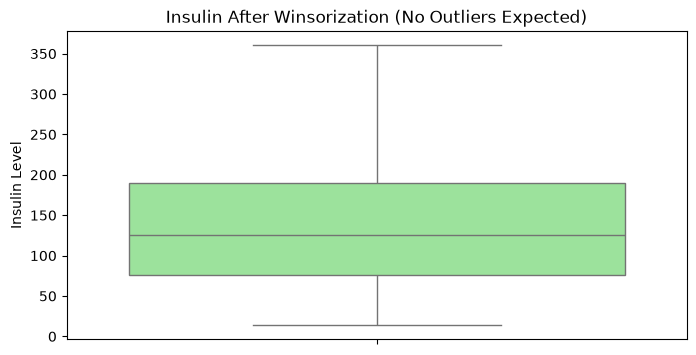


New Statistics for Insulin:
count    394.000000
mean     146.500000
std       90.348842
min       14.000000
25%       76.250000
50%      125.000000
75%      190.000000
max      360.625000
Name: Insulin, dtype: float64


In [10]:
Q1 = df['Insulin'].quantile(0.25)
Q3 = df['Insulin'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Applying Winsorization to Insulin...")
print(f"Capping range: [{lower_bound:.2f}, {upper_bound:.2f}]")


df.loc[df['Insulin'] < lower_bound, 'Insulin'] = lower_bound
df.loc[df['Insulin'] > upper_bound, 'Insulin'] = upper_bound

plt.figure(figsize=(8, 4))
sns.boxplot(y=df['Insulin'], color='lightgreen')
plt.title('Insulin After Winsorization (No Outliers Expected)')
plt.ylabel('Insulin Level')
plt.show()

print("\nNew Statistics for Insulin:")
print(df['Insulin'].describe())

In [14]:
from sklearn.impute import KNNImputer
df_filled = df.copy() 
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

imputer = KNNImputer(n_neighbors=5)
df_filled[cols_to_impute] = imputer.fit_transform(df_filled[cols_to_impute])


print("Missing values after Imputation:")
print(df_filled.isnull().sum())


df = df_filled
print("\nData is ready for Scaling and Modeling!")


if 'Insulin_log' in df.columns:
    df.drop(columns=['Insulin_log'], inplace=True)
    print("'Insulin_log' column dropped.")


print("\nFinal check for missing values:")
print(df.isnull().sum())

Missing values after Imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Data is ready for Scaling and Modeling!

Final check for missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


#### KNN: заполнение пропусков методом K ближайших соседей

#### Что это такое?
KNN Imputer — продвинутый алгоритм импутации, который использует сходство между объектами в датасете для предсказания пропусков.

#### Как работает?
1. Для каждой строки с пропуском (NaN) алгоритм вычисляет "расстояние" до всех остальных строк (обычно Евклидово).
2. Находятся K строк (`n_neighbors=5`), которые находятся ближе всего — это "ближайшие соседи".
3. Пропущенное значение заполняется средним арифметическим значений этого признака у найденных соседей.

#### Почему это лучше простого заполнения средним/медианой?
- Простое заполнение средним игнорирует связи между признаками (например, заполнит инсулин 20-летней и 60-летней одинаково).
- KNN учитывает многомерное пространство признаков: находит похожих пациентов и заполняет пропуск на основе именно их показателей.

#### Важные нюансы
- **Чувствительность к масштабу:** признаки с большим диапазоном (Insulin до 800) доминируют над признаками с малым (Pregnancies до 17). Перед KNN данные желательно масштабировать (`StandardScaler`).
- **Выбор K:** слишком малое K (1) чувствительно к шуму, слишком большое — размывает индивидуальные особенности. Значение 5–7 — стандартный эмпирический выбор.

#### Применение в этом проекте
Применяем импутер только к колонкам `['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']`, потому что нули в них — артефакты сбора данных (медицински невозможные значения). Колонки `Pregnancies` (где 0 — норма) и `Outcome` (целевая переменная) не трогаем, чтобы избежать **data leakage**.